In [44]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [45]:
from salishsea_tools import evaltools as et

In [46]:
# N_1 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/dfo-2023-2024-Nutrients.csv',skiprows=1,parse_dates=['UTC'])
# N_1['UTC'] = N_1['UTC'].dt.tz_localize(None)
# N_1['UTC'] = N_1['UTC'].astype('datetime64[ns]')

# N_1 = N_1[N_1['umol/L']>=0]
# N_1 = N_1[N_1['m']>=0].reset_index(drop=True)

# N_1 = N_1.rename(columns={"degrees_north": "Lat", "degrees_east": "Lon",'UTC':'dtUTC','m':'Z','umol/L':'Nitrate'})

In [47]:
# N_2 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/KC_2023-2025.csv',index_col=False) #*71.39
# N_2['Sample_Date'] = N_2['Sample_Date'].astype('datetime64[ns]')

# N_2 = N_2[N_2['NO23_field']>=0]
# N_2 = N_2[N_2['Sample_Depth']>=0].reset_index(drop=True)
# N_2 = N_2.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Sample_Date':'dtUTC','Sample_Depth':'Z','NO23_field':'Nitrate'})[["Lat","Lon","dtUTC","Z","Nitrate"]]

# N_2 = N_2.drop_duplicates().reset_index(drop=True)

In [48]:
# N_3 = pd.read_excel('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/PSF_N_2015-2023.xlsx',header=[0],skiprows =[1])

# N_3['dtUTC'] = (pd.to_datetime(N_3['date'].astype(str) + ' ' + N_3['time'].astype(str))
#     .dt.tz_localize('America/Vancouver')
#     .dt.tz_convert('UTC')
#     .dt.tz_localize(None))
# N_3['no3'] = N_3['no3'].astype(float)
# N_3 = N_3[N_3['no3']>=0]
# N_3 = N_3[N_3['depth']>=0].reset_index(drop=True)
# N_3 = N_3.rename(columns={"latitude": "Lat", "longitude": "Lon",'depth':'Z','no3':'Nitrate'})[["Lat","Lon","dtUTC","Z","Nitrate"]]

In [49]:
# data_N = pd.concat([N_1,N_2,N_3])

In [50]:
# filemap={'nitrate':'biol_T'}

# #fdict={'biol_T':1}
# # path = f'/data/jvalenti/results'
# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2025,12,31) 

In [51]:
# # data=et.matchData(data_N,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# # data.to_csv('N_23-25_SHEM.csv')

# # path = '/results2/SalishSea/nowcast-green.202111'

# # data=et.matchData(data_N,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# # data.to_csv('N_23-25_20211.csv')

# path = '/ocean/atall/MOAD/Model/202606/'
# fdict={'biol_T':24}

# data=et.matchData(data_N,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('N_23-25_202606.csv')

In [52]:
# #Combine all versions in single file
# data= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/N_23-25_SHEM.csv')
# data = data.rename(columns={'mod_nitrate':'SHEM'})
# data2= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/N_23-25_20211.csv')
# data['v202111']=data2['mod_nitrate']
# data3= pd.read_csv('N_23-25_202606.csv')
# data['v202606']=data3['mod_nitrate']

# data.to_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/N_whole_all_v2.csv')

In [53]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()
    cor = np.corrcoef(obs, predicted)[0, 1]
    print(f"RMSE: {rmse_val}, Bias: {bias}, Willmott Index: {WI}, N: {len(obs)},Nmod: {len(predicted)}, Correlation: {cor}")
    return rmse_val, bias,WI,len(obs)

In [54]:
data = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/N_whole_all_v2.csv') 
latmax = 47.97417#N_2.Lat.max()
data.loc[data['Lat'] < latmax, 'Nitrate'] *= 71.39

In [55]:
i_min = 82 
i_max = 292
j_min = 255
j_max = 735

data_inside = data[(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]
data_outside = data[~(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]

In [56]:
def plot_var(ax,data,name = "SHEM",var='DO_field',reg = 'inside',logscale = False,scatter =False,valim=[-1,45],namevar = 'Nitrate',valmin=0,title=False):
    model = np.array(data[name])
    obs = np.array(data[var])
    depth = np.array(data['Z'])
    mask_N = (obs > valmin) & (~np.isnan(model))
    rmse, bias, WI,N = calculate_rmse_bias(obs[mask_N], model[mask_N])

    if reg == "inside":
        cmapa, ctext, haa, vaa, xx, yy = 'Reds', 'red', 'left', 'top', 0.02, 0.98
    else:
        cmapa, ctext, haa, vaa, xx, yy = 'Greys','k', 'right', 'bottom', 0.98,0.02

    if scatter:
        ax.scatter(obs[mask_N],model[mask_N], alpha=0.6,color=ctext)
        ax.set_xlabel(f'{namevar}_observed')
    elif logscale:
        ax.hexbin(np.log10(obs[mask_N]+0.001), np.log10(model[mask_N]+0.001),gridsize=80, norm=mpl.colors.LogNorm(),cmap=cmapa)#,C=depth[mask_N])
        ax.set_xlabel(f'log({namevar}_observed)')
    else:
        ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=mpl.colors.LogNorm(),cmap=cmapa)#,C=depth[mask_N])
        ax.set_xlabel(f'{namevar}_observed')

    
    if title:
        ax.set_title(f'{name} vs Observed 2023 - 2025')
        
    ax.plot(np.linspace(valim[0], valim[1]),np.linspace(valim[0],valim[1]),'r--')
    s = f"{N:.0e}"
    s = s.replace("e+0", "e").replace("e+", "e").replace("e-0", "e-")
    ax.text(xx, yy,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',transform=ax.transAxes,ha=haa,va=vaa,color=ctext)

    ax.set_xlim(valim[0],valim[1])
    ax.set_ylim(valim[0],valim[1])

RMSE: 6.996691281550182, Bias: -5.975605584404268, Willmott Index: 0.6682601766831335, N: 255696,Nmod: 255696, Correlation: 0.74434560439837
RMSE: 5.8448022992301185, Bias: -4.305682831926666, Willmott Index: 0.6925768869931948, N: 255696,Nmod: 255696, Correlation: 0.6702283753367463
RMSE: 5.143450502887239, Bias: -3.836272770819658, Willmott Index: 0.7577521968178937, N: 255696,Nmod: 255696, Correlation: 0.7679028385912591
RMSE: 4.592523488370832, Bias: -1.4789680954610467, Willmott Index: 0.9221492454829348, N: 2098,Nmod: 2098, Correlation: 0.8690132443697007
RMSE: 4.3619126647270825, Bias: -1.7166092346664747, Willmott Index: 0.9128427000122457, N: 2098,Nmod: 2098, Correlation: 0.8685712302354225
RMSE: 4.359887935155228, Bias: 0.9781395240829774, Willmott Index: 0.9209705594041955, N: 2098,Nmod: 2098, Correlation: 0.8572416697666301


Text(0, 0.5, 'Nitrate model [mmol/m3]')

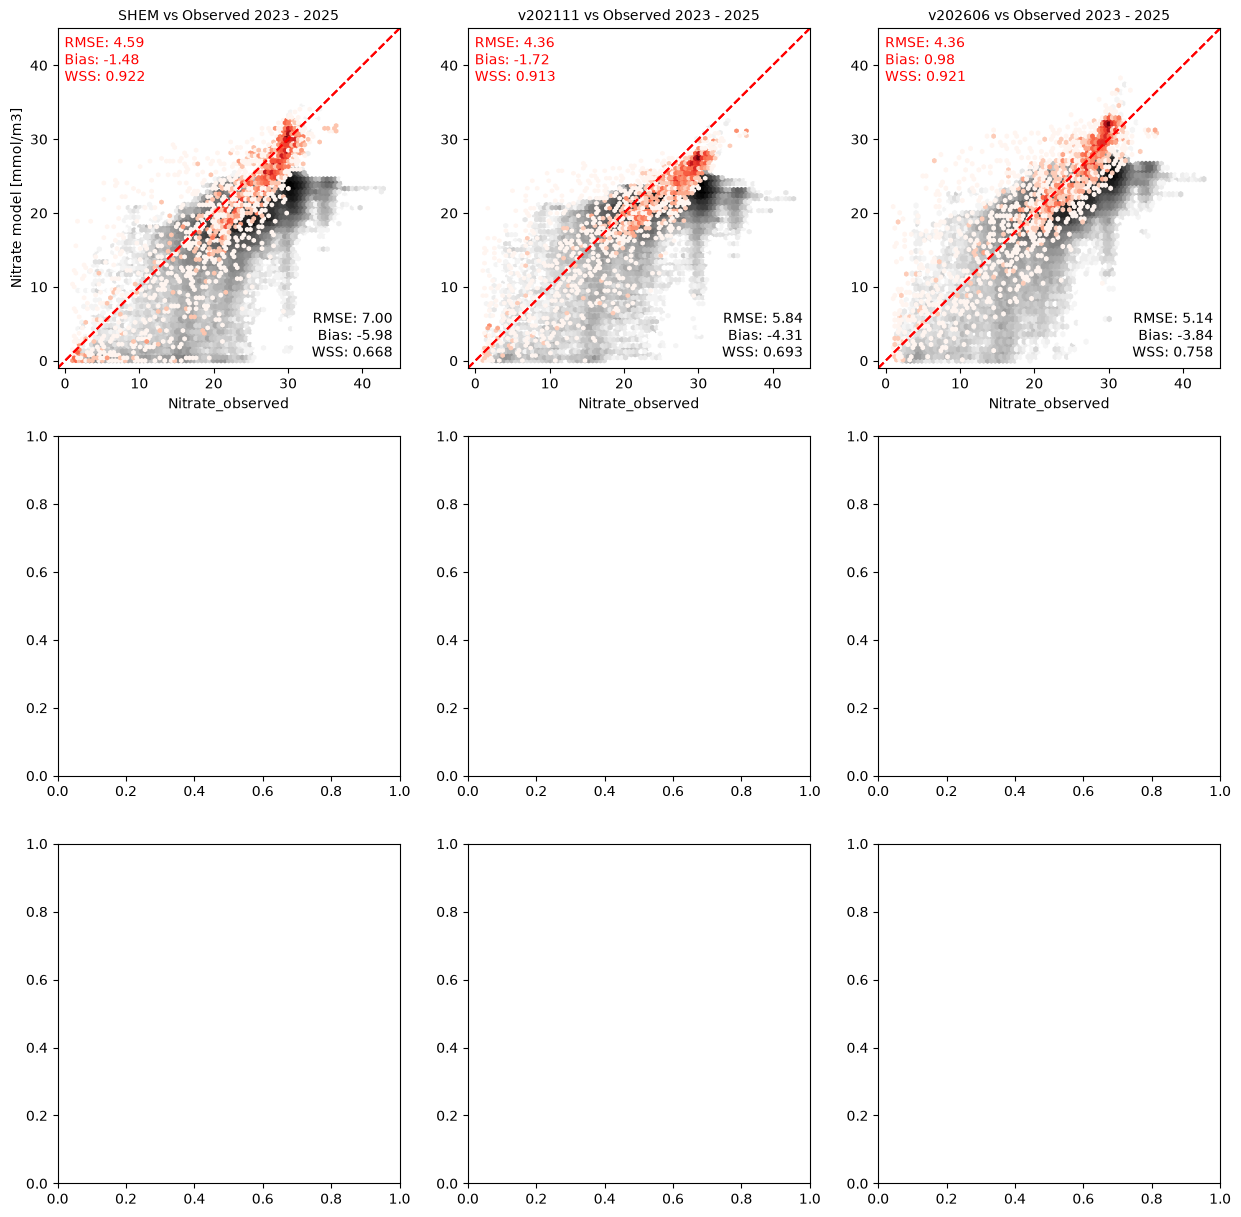

In [57]:
fig, axs = plt.subplots(3,3,figsize=(15,15))

plot_var(axs[0,0],data_outside,'SHEM',reg='outside',var ='Nitrate',valmin=1,title=True)
plot_var(axs[0,1],data_outside,'v202111',reg='outside',var ='Nitrate',valmin=1,title=True)
plot_var(axs[0,2],data_outside,'v202606',reg='outside',var ='Nitrate',valmin=1,title=True)

plot_var(axs[0,0],data_inside,'SHEM',var ='Nitrate',valmin=1,title=True)
plot_var(axs[0,1],data_inside,'v202111',var ='Nitrate',valmin=1,title=True)
plot_var(axs[0,2],data_inside,'v202606',var ='Nitrate',valmin=1,title=True)

axs[0,0].set_ylabel('Nitrate model [mmol/m3]')

In [58]:
# data= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/DO_puget_2025_all.csv')
# data2= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/O2_2025_all.csv')

# data_tot = data[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]
# data_tot['DO_field'] = data_tot['DO_field']*31.25
# data2_tot = data2.rename(columns={'o2uM':'DO_field','SHEM_DO':'SHEM','v202410_DO':'v202410','v202111_DO':'v202111'})
# data2_tot = data2_tot[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]

# data_tot_25 = pd.concat([data_tot,data2_tot])

In [59]:
# data= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/DO_puget_2023_all.csv')
# data2 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/DO_2023_all.csv')

# data_tot_23 = data[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]
# data_tot_23['DO_field'] = data_tot_23['DO_field']*31.25

# data2_tot = data2.rename(columns={'DOXYZZ01':'DO_field'})
# data2_tot['DO_field'] = data2_tot['DO_field']*44.66
# data2_tot = data2_tot[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]

# data_tot_23 = pd.concat([data_tot_23,data2_tot])

In [60]:
# data= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/DO_puget_2024_all.csv')
# data2 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/O2_2024_all.csv')

# data_tot_24 = data[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]
# data_tot_24['DO_field'] = data_tot_24['DO_field']*31.25

# data2_tot = data2.rename(columns={'DOXYZZ01':'DO_field'})
# data2_tot['DO_field'] = data2_tot['DO_field']*44.66
# data2_tot = data2_tot[["dtUTC", "Z","DO_field","Lat","Lon","SHEM","j","i","v202111","v202410"]]

# data_tot_24 = pd.concat([data_tot_24,data2_tot])

In [61]:
# data_tot = pd.concat([data_tot_25,data_tot_24,data_tot_23])

# data_tot['dtUTC'] = data_tot['dtUTC'].astype('datetime64[ns]')

In [62]:
# filemap={'dissolved_oxygen':'chem_T'}

# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2025,12,31) 

# path = '/ocean/atall/MOAD/Model/202606/'
# fdict={'chem_T':24}

# data=et.matchData(data_tot,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('DO_23-25_202606.csv')

In [63]:
data = pd.read_csv('DO_23-25_202606.csv')

In [64]:
i_min = 82 
i_max = 292
j_min = 255
j_max = 735
data = data.rename(columns={'mod_dissolved_oxygen':'v202606'})
data_inside = data[(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]
data_outside = data[~(data["i"].between(i_min, i_max) & data["j"].between(j_min, j_max))]

RMSE: 26.34227174395421, Bias: -8.090456014816029, Willmott Index: 0.924932143510009, N: 408410,Nmod: 408410, Correlation: 0.8708439500362756
RMSE: 22.637384181328798, Bias: -7.1904436802395955, Willmott Index: 0.9359611759373635, N: 408410,Nmod: 408410, Correlation: 0.8941179119841287
RMSE: 28.387800259790392, Bias: -12.819277299176756, Willmott Index: 0.9111184720184804, N: 408410,Nmod: 408410, Correlation: 0.8629191206648098
RMSE: 32.39629002840693, Bias: -10.285894791298823, Willmott Index: 0.9024251305402518, N: 192007,Nmod: 192007, Correlation: 0.8386967187081831
RMSE: 25.368302067770397, Bias: 8.621359055841896, Willmott Index: 0.9203210355227832, N: 192007,Nmod: 192007, Correlation: 0.8859809836329047
RMSE: 29.015865616001353, Bias: -8.212027541690663, Willmott Index: 0.910240663684396, N: 192007,Nmod: 192007, Correlation: 0.844264143884978


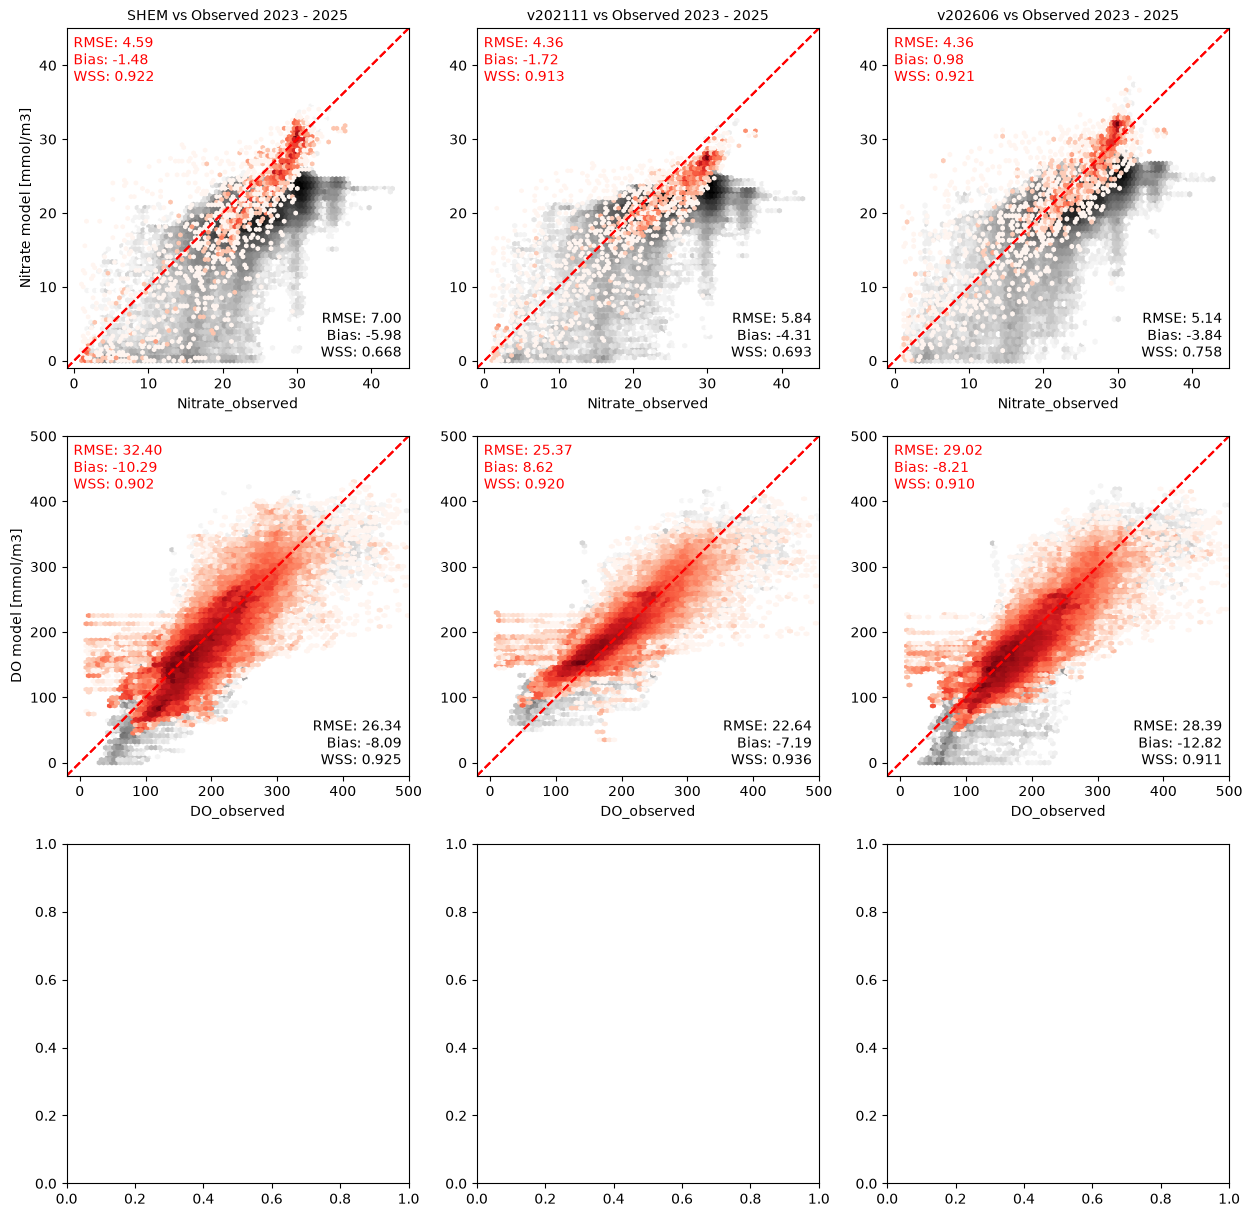

In [65]:
#fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)

plot_var(axs[1,0],data_outside,'SHEM',reg='outside',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)
plot_var(axs[1,1],data_outside,'v202111',reg='outside',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)
plot_var(axs[1,2],data_outside,'v202606',reg='outside',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)

plot_var(axs[1,0],data_inside,'SHEM',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)
plot_var(axs[1,1],data_inside,'v202111',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)
plot_var(axs[1,2],data_inside,'v202606',var='DO_field',valim=[-20,500],namevar="DO",valmin=10)

axs[1,0].set_ylabel('DO model [mmol/m3]')

fig

In [ ]:
# chl_1 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/dfo_chl.csv',header=[0],skiprows=[1],parse_dates=['time']) #mg/m^3
# chl_1['time'] = chl_1['time'].dt.tz_localize(None)
# chl_1['time'] = chl_1['time'].astype('datetime64[ns]')

# chl_1 = chl_1[chl_1['CPHLFLP1']>=0]
# chl_1 = chl_1[chl_1['depth']>=0].reset_index(drop=True)

# chl_1 = chl_1.rename(columns={"latitude": "Lat", "longitude": "Lon",'time':'dtUTC','depth':'Z','CPHLFLP1':'Chl'})[["Lat","Lon","dtUTC","Z","Chl"]]

In [ ]:
# chl_2 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/KC_2023-2025.csv',index_col=False) 
# chl_2['Sample_Date'] = chl_2['Sample_Date'].astype('datetime64[ns]')

# chl_2 = chl_2[chl_2['Chla_field']>=0]
# chl_2 = chl_2[chl_2['Sample_Depth']>=0].reset_index(drop=True)
# chl_2 = chl_2.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Sample_Date':'dtUTC','Sample_Depth':'Z','Chla_field':'Chl'})[["Lat","Lon","dtUTC","Z","Chl"]]

# chl_2 = chl_2.drop_duplicates().reset_index(drop=True)

/tmp/ipykernel_2330213/3387118355.py:1: DtypeWarning: Columns (0: DO_Qual, 1: NO23_Qual, 2: CH_Qual) have mixed types. Specify dtype option on import or set low_memory=False.
  chl_2 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/KC_2023-2025.csv',index_col=False)


In [ ]:
# chl_3 = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/SHEM_eval/PSF_CTD_2025-2026.csv',header = [6],skiprows=[7],parse_dates=['datetime'])
# chl_3['datetime'] = chl_3['datetime'].astype('datetime64[ns]')

# chl_3['chl'] = chl_3['chl'].astype(float)
# chl_3 = chl_3[chl_3['chl']>=0]
# chl_3 = chl_3[chl_3['depth']>=0].reset_index(drop=True)
# chl_3 = chl_3.rename(columns={"latitude": "Lat", "longitude": "Lon",'depth':'Z','chl':'Chl','datetime':'dtUTC'})[["Lat","Lon","dtUTC","Z","Chl"]]

In [ ]:
# data_chl = pd.concat([chl_1,chl_2,chl_3]).reset_index(drop=True)

In [ ]:
# filemap={'diatoms':'biol_T','flagellates':'biol_T'}

# # fdict={'biol_T':1}
# # path = f'/data/jvalenti/results'
# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

# # start_date = dt.datetime(2023,1,1) 
# # end_date = dt.datetime(2025,12,31) 

In [78]:
# # data=et.matchData(data_chl,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# # data.to_csv('chl_23-25_SHEM.csv')

# # path = '/results2/SalishSea/nowcast-green.202111'
# # fdict={'biol_T':1}

# # data=et.matchData(data_chl,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# # data.to_csv('chl_23-25_202111.csv')


# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2025,12,31) 

# path = '/ocean/atall/MOAD/Model/202606/'

# fdict={'biol_T':24}

# data=et.matchData(data_chl,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('chl_23-25_202606.csv')

In [ ]:
# # #Combine all versions in single file
# data= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/chl_23-25_SHEM.csv')
# data = data.rename(columns={'mod_diatoms':'SHEM_diatoms','mod_flagellates':'SHEM_flagellates'})
# data2= pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/chl_23-25_202111.csv')
# data3= pd.read_csv('chl_23-25_202606.csv')
# data['SHEM']=(data['SHEM_flagellates']+data['SHEM_diatoms'])*1.6

# data['v202111_diatoms']=data2['mod_diatoms']
# data['v202111_flagellates']=data2['mod_flagellates']
# data['v202111']=(data['v202111_flagellates']+data['v202111_diatoms'])*1.6

# data['v202606_diatoms']=data3['mod_diatoms']
# data['v202606_flagellates']=data3['mod_flagellates']
# data['v202606']=(data['v202606_flagellates']+data['v202606_diatoms'])*1.6

# data.to_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/chl_whole_all_v2.csv')

In [77]:
data_tot = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/chl_whole_all_v2.csv')

In [79]:
i_min = 82 
i_max = 292
j_min = 255
j_max = 735

data_inside = data_tot[(data_tot["i"].between(i_min, i_max) & data_tot["j"].between(j_min, j_max))]
data_outside = data_tot[~(data_tot["i"].between(i_min, i_max) & data_tot["j"].between(j_min, j_max))]

In [80]:
#fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
axs[2,0].clear()
axs[2,1].clear()
axs[2,2].clear()

plot_var(axs[2,0],data_outside,'SHEM',reg='outside',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)
plot_var(axs[2,1],data_outside,'v202111',reg='outside',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)
plot_var(axs[2,2],data_outside,'v202606',reg='outside',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)

plot_var(axs[2,0],data_inside,'SHEM',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)
plot_var(axs[2,1],data_inside,'v202111',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)
plot_var(axs[2,2],data_inside,'v202606',var = 'Chl',valim=[-3,2],namevar='Chl',logscale=True)

axs[2,0].set_ylabel('log(Chl model) [mg/m3]')

RMSE: 1.2787012235093824, Bias: -0.14972003178905005, Willmott Index: 0.6856078532277583, N: 286618,Nmod: 286618, Correlation: 0.5663825974464587
RMSE: 1.222105145805427, Bias: -0.10216299035056688, Willmott Index: 0.7291131835809834, N: 286618,Nmod: 286618, Correlation: 0.6109497308046579
RMSE: 1.2234966858965552, Bias: -0.09108857898224546, Willmott Index: 0.735406263644304, N: 286618,Nmod: 286618, Correlation: 0.612341970037571
RMSE: 3.6614412096233973, Bias: -0.8568730623812894, Willmott Index: 0.3981175962197293, N: 20505,Nmod: 20505, Correlation: 0.43641280640174107
RMSE: 3.662408402418297, Bias: -0.8471123848115008, Willmott Index: 0.382841436300976, N: 20505,Nmod: 20505, Correlation: 0.44315189987045955
RMSE: 3.663403881507934, Bias: -0.8245984830351616, Willmott Index: 0.3831036091041128, N: 20505,Nmod: 20505, Correlation: 0.43190517098841996


Text(0, 0.5, 'log(Chl model) [mg/m3]')

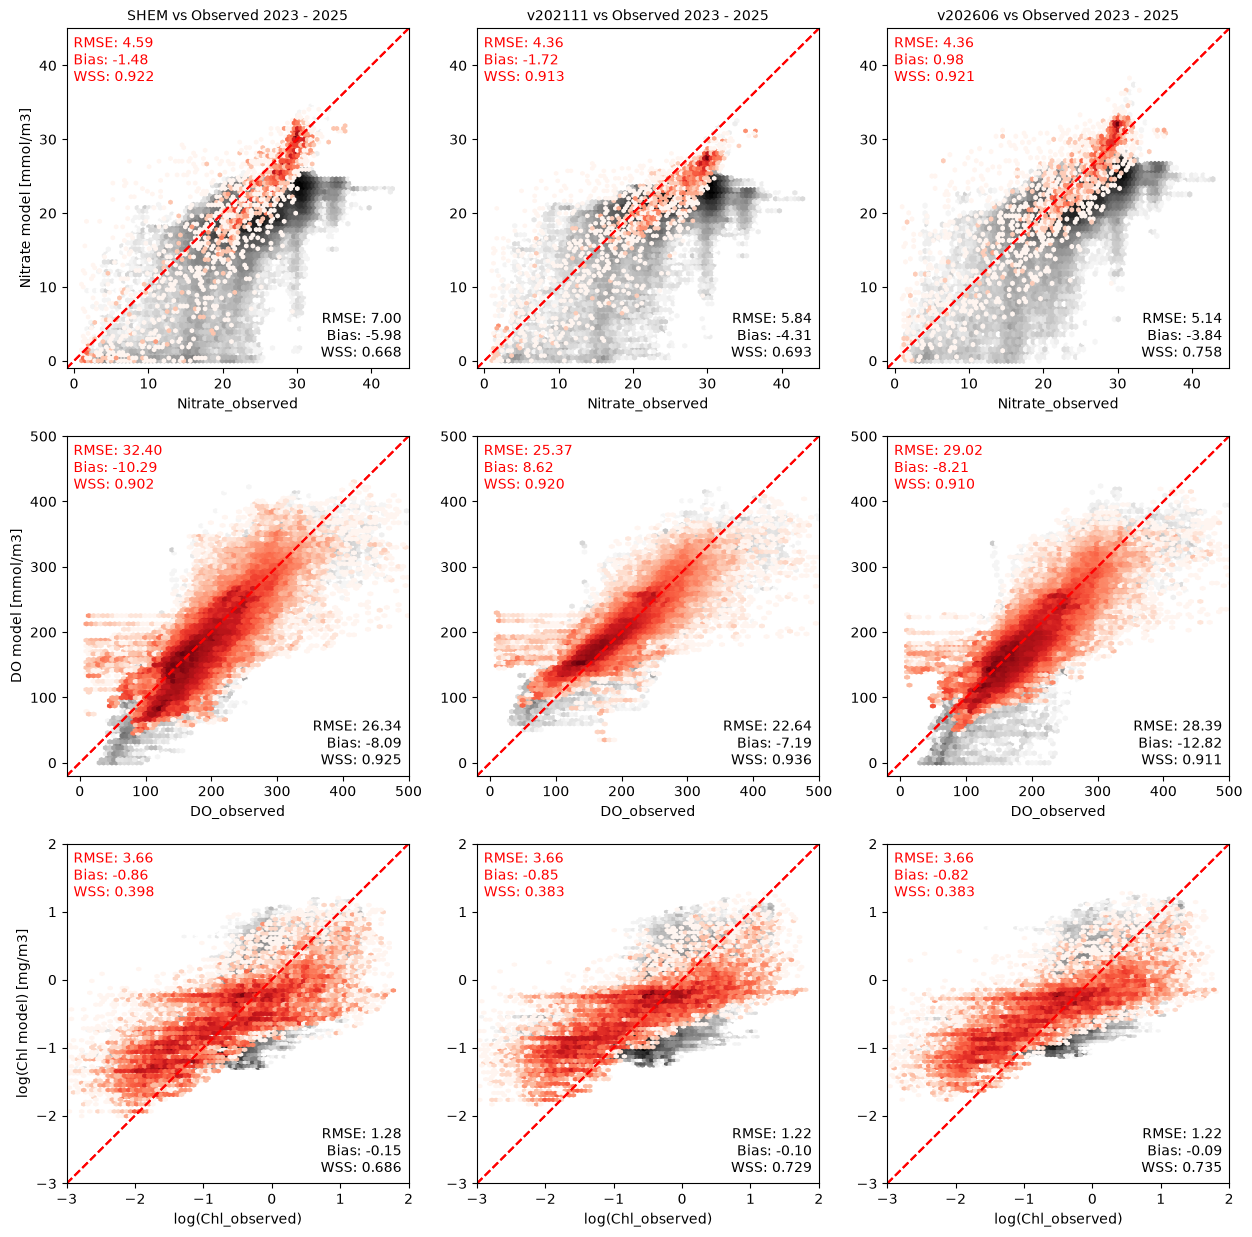

In [81]:
fig

In [82]:
fig.savefig('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/figures/full_eval_v2.pdf',bbox_inches='tight')